In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("comtrade_natural_gas_clean.csv")
# df.head()
df.tail()





,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,...,isNetWgtEstimated,primaryValue,isAggregate,reporter,partner,flow,transport,qty_type,alt_qty_type,customs_type
100465,2025-11-01,2025,11,757,M,276,H6,271121,C01,3200,...,False,2.300490e+03,False,Switzerland,Germany,Import,Road,kg,Weight in kilograms,Clearance for home use
100466,2025-11-01,2025,11,757,M,528,H6,271111,C01,3200,...,False,1.297725e+04,False,Switzerland,Netherlands,Import,Road,kg,Volume in liters,Clearance for home use
100467,2025-11-01,2025,11,757,M,634,H6,271111,C01,3200,...,False,8.423897e+04,False,Switzerland,Qatar,Import,Road,kg,Volume in liters,Clearance for home use
100468,2025-11-01,2025,11,757,M,380,H6,271111,C01,3200,...,False,2.785583e+04,False,Switzerland,Italy,Import,Road,kg,Volume in liters,Clearance for home use
100469,2025-10-01,2025,10,826,X,56,H6,271121,C00,9100,...,False,7.831825e+07,False,United Kingdom,Belgium,Export,Pipelines and cables,kg,Terajoule (gross calorific value),TOTAL CPC


In [16]:
# Ensuring correct dtypes
df["period"] = pd.to_datetime(df["period"])
df["primaryValue"] = pd.to_numeric(df["primaryValue"], errors="coerce")
df["netWgt"] = pd.to_numeric(df["netWgt"], errors="coerce")

df = df[df["primaryValue"].notna() & (df["primaryValue"] >= 0)]

In [17]:
df["cmdCode"] = df["cmdCode"].astype(str)
df["product"] = np.where(
    df["cmdCode"] == "271111",
    "LNG (271111)",
    "Gaseous NG (271121)"
)

df["product"].value_counts()



product
LNG (271111)           53663
Gaseous NG (271121)    46807
Name: count, dtype: int64

In [18]:

df_2010 = df[(df["refYear"] >= 2010) & (df["refYear"] < 2025)].copy()
df_2010.head()


,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,...,primaryValue,isAggregate,reporter,partner,flow,transport,qty_type,alt_qty_type,customs_type,product
8944,2010-01-01,2010,1,56,X,792,H3,271111,C00,0,...,2.080427e+07,False,Belgium,Turkey,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,LNG (271111)
8945,2010-01-01,2010,1,56,X,826,H3,271121,C00,0,...,9.716870e+07,False,Belgium,United Kingdom,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)
8946,2010-01-01,2010,1,56,X,276,H3,271121,C00,0,...,1.044149e+07,False,Belgium,Germany,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)
8947,2010-01-01,2010,1,56,X,528,H3,271121,C00,0,...,7.802086e+07,False,Belgium,Netherlands,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)
8948,2010-01-01,2010,1,56,X,442,H3,271121,C00,0,...,2.272164e+07,False,Belgium,Luxembourg,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)


## Global trade evolution (Basic Trend Analysis)

Goal: Establish baseline trends in global natural gas trade.  
We aggregate total imports vs exports and compare LNG vs gaseous gas using annual and **monthly time series.


In [19]:
def comp_annual_trade(df):
    """
    Aggregate trade values by year, flow, and product,
    then pivot to get Import/Export and net trade.
    """
    annual_val = (
        df
        .groupby(["refYear", "flow", "product"], as_index=False)
        .agg(value_usd=("primaryValue", "sum"))
    )

    annual_val_piv = (
        annual_val
        .pivot_table(
            index=["refYear", "product"],
            columns="flow",
            values="value_usd",
            fill_value=0
        )
        .reset_index()
    )

    annual_val_piv["net_trade_usd"] = (
        annual_val_piv.get("Export", 0) - annual_val_piv.get("Import", 0)
    )

    return annual_val_piv

annual_val_piv = comp_annual_trade(df_2010)


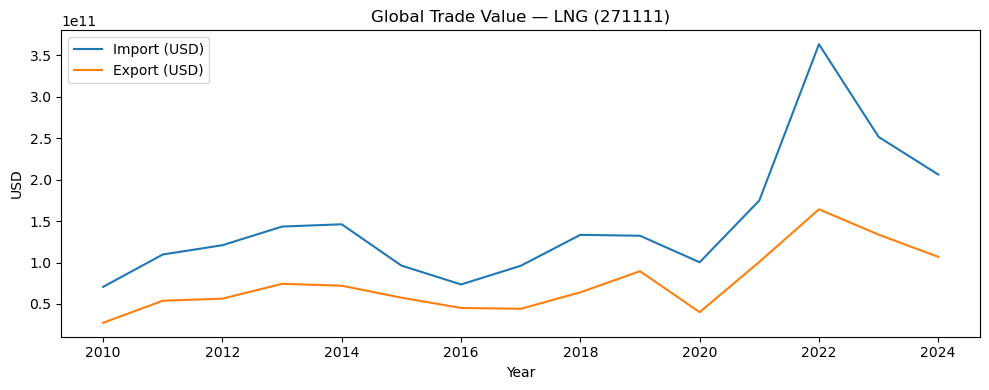

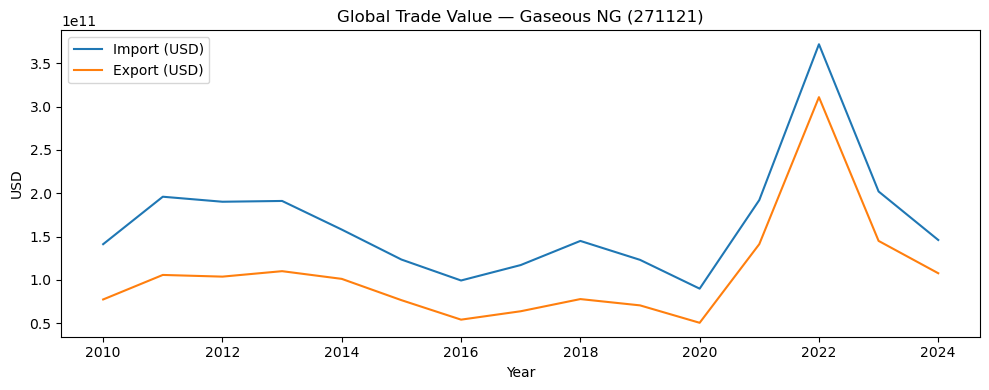

In [20]:
def plot_trade_by_product(df, products, start_year=None,figsize=(10, 4)):
    """
    Plot Import and Export values over time for given products.
    """
    for prod in products:
        tmp = df[df["product"] == prod].sort_values("refYear")

        if start_year is not None:
            tmp = tmp[tmp["refYear"] >= start_year]

        plt.figure(figsize=figsize)
        plt.plot(tmp["refYear"], tmp.get("Import", 0), label="Import (USD)")
        plt.plot(tmp["refYear"], tmp.get("Export", 0), label="Export (USD)")
        plt.title(f"Global Trade Value — {prod}")
        plt.xlabel("Year")
        plt.ylabel("USD")
        plt.legend()
        plt.tight_layout()
        plt.show()

products = ["LNG (271111)", "Gaseous NG (271121)"]

plot_trade_by_product(
    annual_val_piv,
    products,
    start_year=2010
)



These figures show the evolution of global LNG and pipeline gas trade values since 2010. Both markets exhibit a clear structural break in 2022, with a sharp increase in trade values driven by the energy crisis, due to the starting of the Russia-Ukraine war.

LNG trade demonstrates greater flexibility, with values adjusting primarily through prices and subsequent normalization. In contrast, pipeline gas trade shows a sharper collapse after the crisis, reflecting the refional rigidity and its vulnerability to supply disruptions

In the next couple of graphs we see how the results were price driven and not directly correlated to the increase in volumes

In [21]:
df_lng = df_2010[
    (df_2010["product"] == "LNG (271111)") &
    (df_2010["netWgt"].notna()) &
    (df_2010["netWgt"] > 0)
].copy()

print("Rows (LNG with netWgt):", len(df_lng))

df_lng = df_lng[df_lng["isNetWgtEstimated"] == False].copy()

lng_reporter_year = (
    df_lng
    .groupby(["refYear", "flow", "reporterCode", "reporter"], as_index=False)
    .agg(netWgt_kg=("netWgt", "mean"))
)

lng_reporter_year.head()





Rows (LNG with netWgt): 45029


,refYear,flow,reporterCode,reporter,netWgt_kg
0,2010,Export,12,Algeria,2.552279e+08
1,2010,Export,32,Argentina,1.000000e+00
2,2010,Export,51,Armenia,8.000000e-01
3,2010,Export,56,Belgium,5.480876e+07
4,2010,Export,72,Botswana,2.079333e+03


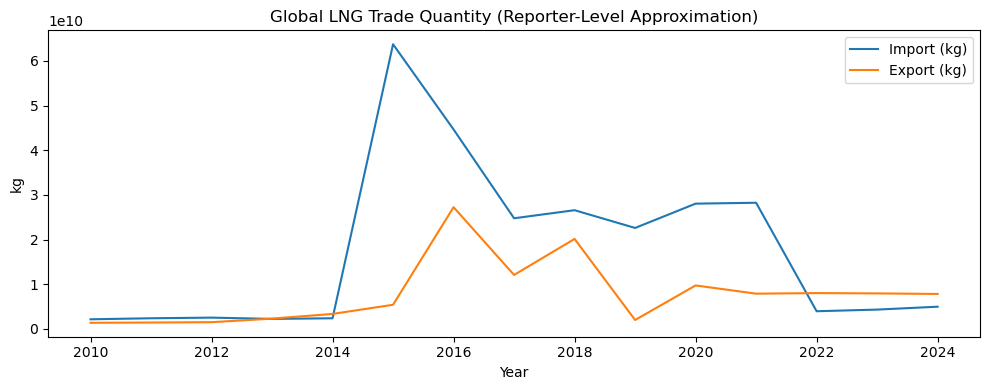

In [22]:
global_lng_qty = (
    lng_reporter_year
    .groupby(["refYear", "flow"], as_index=False)
    .agg(global_netWgt_kg=("netWgt_kg", "sum"))
)

global_lng_qty.head()

global_lng_qty_piv = (
    global_lng_qty
    .pivot_table(
        index="refYear",
        columns="flow",
        values="global_netWgt_kg",
        fill_value=0
    )
    .reset_index()
)

global_lng_qty_piv.head()

plt.figure(figsize=(10,4))
plt.plot(global_lng_qty_piv["refYear"], global_lng_qty_piv["Import"], label="Import (kg)")
plt.plot(global_lng_qty_piv["refYear"], global_lng_qty_piv["Export"], label="Export (kg)")
plt.title("Global LNG Trade Quantity (Reporter-Level Approximation)")
plt.xlabel("Year")
plt.ylabel("kg")
plt.legend()
plt.tight_layout()
plt.show()




UN Comtrade reports the netWgt in Kg, so for LNG, since it is transported as cargo, we can use this as a rough/decent estimation. But for pipeline gas, measurement is heterogenous, therefor it is not desirable (I plotted it, the values are unrealistic). In the country specific analysis we can better estimate importers and exporters, therefore this graph is just visual proof of how the 2022 increase in prices were not proportional to volume, and were rather price driven, than volume.

## Continental and Country Specific analysis (Continent Leval Analysis)

Goal: This step identifies regional drivers of global gas demand, distinguishes LNG versus pipeline substitution by region, and shows which regions absorbed the 2022 shock and where LNG replaced pipeline gas.


In [23]:
"""
We mainly focus on imports only to obtain a clean, demand side perespective of natural gas trade. Import data asssign each shipment once and only once to the consuming region.
This avoids double counting and exporter side distortions. Additionally, In UN COMTRADE, imports are recorded cif (cost insurance and freight) while exports are fob (free on board).
This represents an overall difference, Despite all efforts made by national and international agencies, data quality may vary among countries.
For a given country, imports are usually recorded with more accuracy than exports because imports generally generate tariff revenues while exports don't.
At a detailed level, a same good may be recorded in different categories by the exporter and the importer.
"""

# Manual mapping of reporterCode to Continent, maintaing 5 continents for analysis

Africa = [
    12,   # Algeria
    24,   # Angola
    72,   # Botswana
    108,  # Burundi
    120,  # Cameroon
    132,  # Cape Verde
    148,  # Chad
    178,  # Congo
    180,  # DRC
    204,  # Benin
    231,  # Ethiopia
    262,  # Djibouti
    266,  # Gabon
    270,  # Gambia
    288,  # Ghana
    324,  # Guinea
    384,  # Côte d’Ivoire
    404,  # Kenya
    454,  # Malawi
    466,  # Mali
    504,  # Morocco
    516,  # Namibia
    562,  # Niger
    566,  # Nigeria
    646,  # Rwanda
    686,  # Senegal
    710,  # South Africa
    716,  # Zimbawe
    729,  # Sudan
    768,  # Togo
    788,  # Tunisia
    800,  # Uganda
    818   # Egypt
]

Americas = [
    32,   # Argentina
    68,   # Bolivia
    76,   # Brazil
    124,  # Canada
    152,  # Chile
    170,  # Colombia
    188,  # Costa Rica
    214,  # Dominican Republic
    218,  # Ecuador
    222,  # El Salvador
    320,  # Guatemala
    340,  # Honduras
    484,  # Mexico
    558,  # Nicaragua
    591,  # Panama
    600,  # Paraguay
    604,  # Peru
    740,  # Suriname
    858,  # Uruguay
    862,  # Venezuela
    840   # United States
]

Asia = [
    31,   # Azerbaijan
    48,   # Bahrain
    50,   # Bangladesh
    51,   # Armenia
    96,   # Brunei
    104,  # Myanmar
    116,  # Cambodia
    144,   # Sri Lanka
    156,  # China
    196,  # Cyprus 
    275,  # Palestine
    344,  # Hong Kong
    360,  # Indonesia
    364,  # Iran
    376,  # Israel
    392,  # Japan
    398,  # Kazakhstan
    400,  # Jordan
    410,  # South Korea
    414,  # Kuwait
    417,  # Kyrgyzstan
    458,  # Malaysia
    496,  # Mongolia
    512,  # Oman
    524,  # Nepal
    586,  # Pakistan
    608,  # Philippines
    634,  # Qatar
    682,  # Saudi Arabia
    699,  # India
    702,  # Singapore
    704,  # Vietnam
    764,  # Thailand
    784,  # United Arab Emirates
    792,  # Turkey
    860,  # Uzbekistan
    887   # Yemen
]

Europe = [
    8,    # Albania
    40,   # Austria
    56,   # Belgium
    100,  # Bulgaria
    112,  # Belarus
    191,  # Croatia
    203,  # Czech Republic
    208,  # Denmark
    233,  # Estonia
    246,  # Finland
    251,  # France
    276,  # Germany
    300,  # Greece
    348,  # Hungary
    352,  # Iceland
    372,  # Ireland
    380,  # Italy
    428,  # Latvia
    440,  # Lithuania
    442,  # Luxembourg
    470,  # Malta
    499,  # Montenegro
    528,  # Netherlands
    579,  # Norway
    616,  # Poland
    620,  # Portugal
    642,  # Romania
    643,  # Russian Federation
    688,  # Serbia
    703,  # Slovakia
    705,  # Slovenia
    724,  # Spain
    752,  # Sweden
    757,  # Switzerland
    804,  # Ukraine
    807,  # North Macedonia
    826   # United Kingdom
]

Oceania = [
    36,   # Australia
    554,  # New Zealand
    598   # Papua New Guinea
]

continent_map = {
    "Africa": Africa,
    "Americas": Americas,
    "Asia": Asia,
    "Europe": Europe,
    "Oceania": Oceania
}


reporter_to_continent = {
    code: cont
    for cont, codes in continent_map.items()
    for code in codes
}

# Assign continent
df_2010["continent"] = df_2010["reporterCode"].map(reporter_to_continent)

# Check
df_2010["continent"].value_counts(dropna=False)

# Check coverage
coverage = df_2010["continent"].value_counts(dropna=False)
coverage



continent
Europe      45696
Asia        19576
NaN          8253
Africa       7775
Americas     5516
Oceania       469
Name: count, dtype: int64

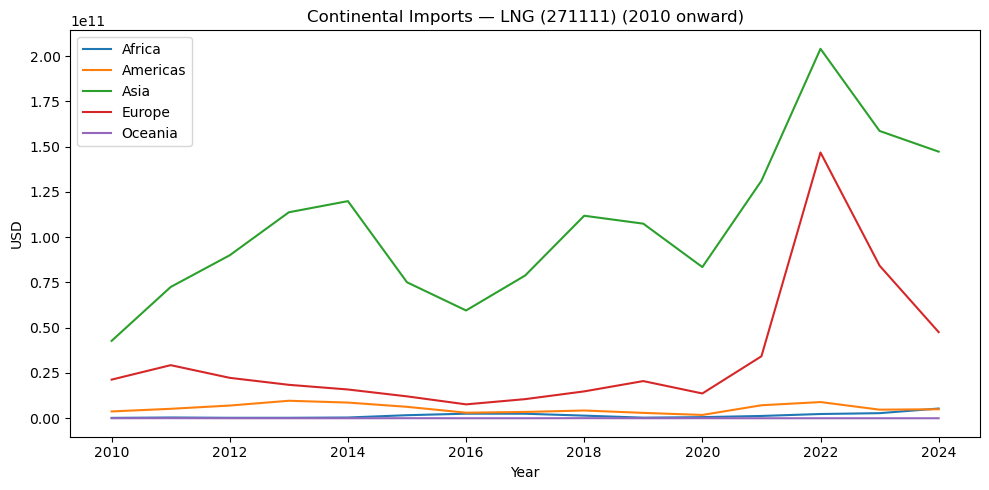

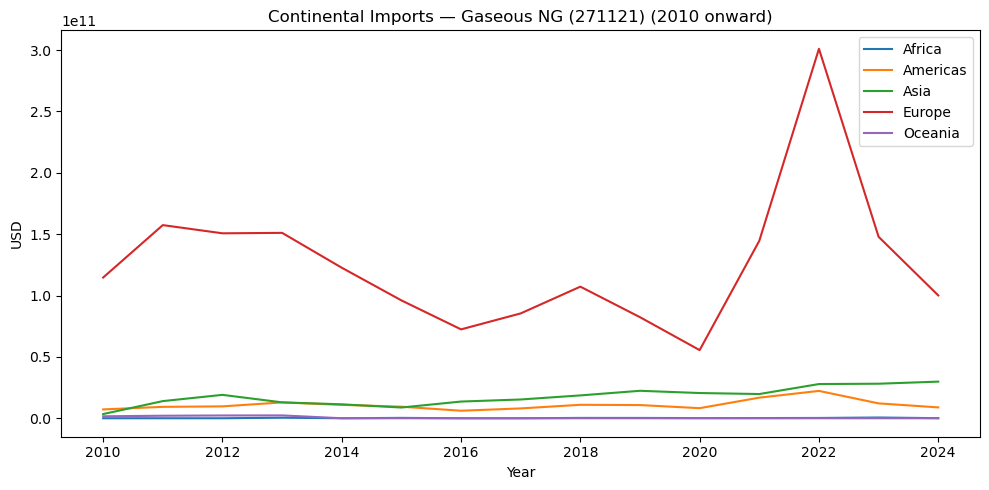

In [24]:
annual_cont = (
    df_2010
    .groupby(["refYear", "continent", "flow", "product"], as_index=False)
    .agg(value_usd=("primaryValue", "sum"))
)

annual_cont.head()

def plot_continental_trade(df, products, flow="Export", start_year=2010, figsize=(10, 5)):
    """
    Plot trade value over time by continent for selected products and flow.
    """
    for prod in products:
        plt.figure(figsize=figsize)

        tmp = df[
            (df["product"] == prod) &
            (df["flow"] == flow) &
            (df["refYear"] >= start_year)
        ]

        for cont in sorted(tmp["continent"].dropna().unique()):
            sub = (
                tmp[tmp["continent"] == cont]
                .sort_values("refYear")
            )
            plt.plot(sub["refYear"], sub["value_usd"], label=cont)

        plt.title(f"Continental {flow}s — {prod} ({start_year} onward)")
        plt.xlabel("Year")
        plt.ylabel("USD")
        plt.legend()
        plt.tight_layout()
        plt.show()

products = ["LNG (271111)", "Gaseous NG (271121)"]

plot_continental_trade(
    annual_cont,
    products,
    flow="Import",
    start_year=2010
)


From the first graph we see, LNG imports are dominated by Asia, but Europe became a major LNG importer after 2022, reflecting emergency substitution away from pipeline gas. Along with that we also notice Americas and Ocenia are minimal importers.

From the second graph we see, that Europe is mainly dependent on pipeline ng thereby explaining the severity of the 2022 impact, while Asia as reconfirmed is primarily dependent on LNG.

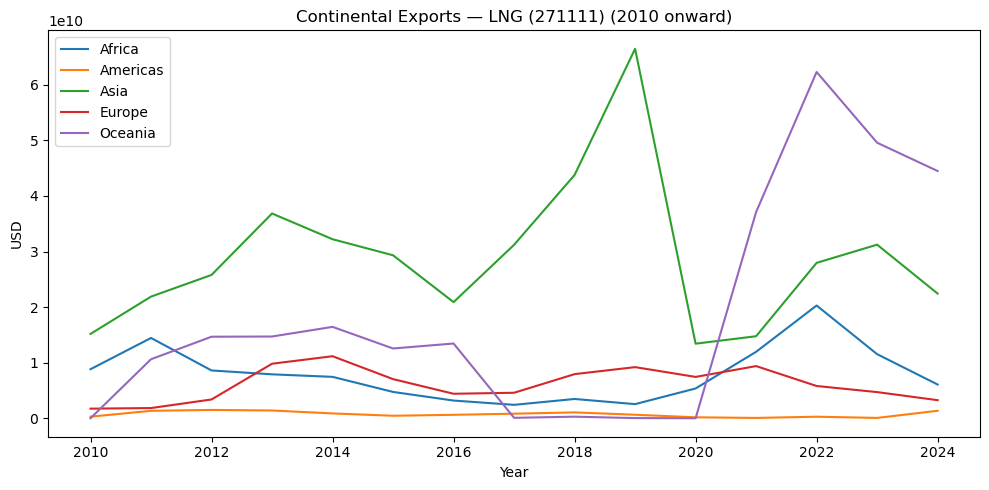

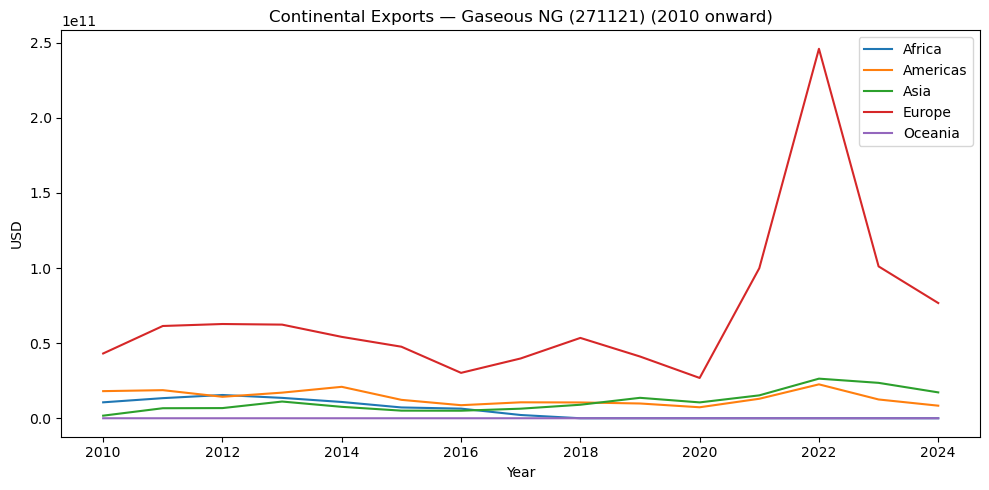

In [25]:
plot_continental_trade(
    annual_cont,
    products,
    flow="Export",
    start_year=2010
)


On the export side, LNG supply is geographically diversified, with Asia dominating early on and Oceania and the Americas gaining importance over time. This diversification allowed LNG markets to respond flexibly during the energy crisis. In contrast, pipeline gas exports as seen are mostly concentrated in Europe, reflecting dependence on a small number of suppliers. The sharp spike and subsequent collapse after 2022 highlight the rigidity and vulnerability of pipeline gas trade.


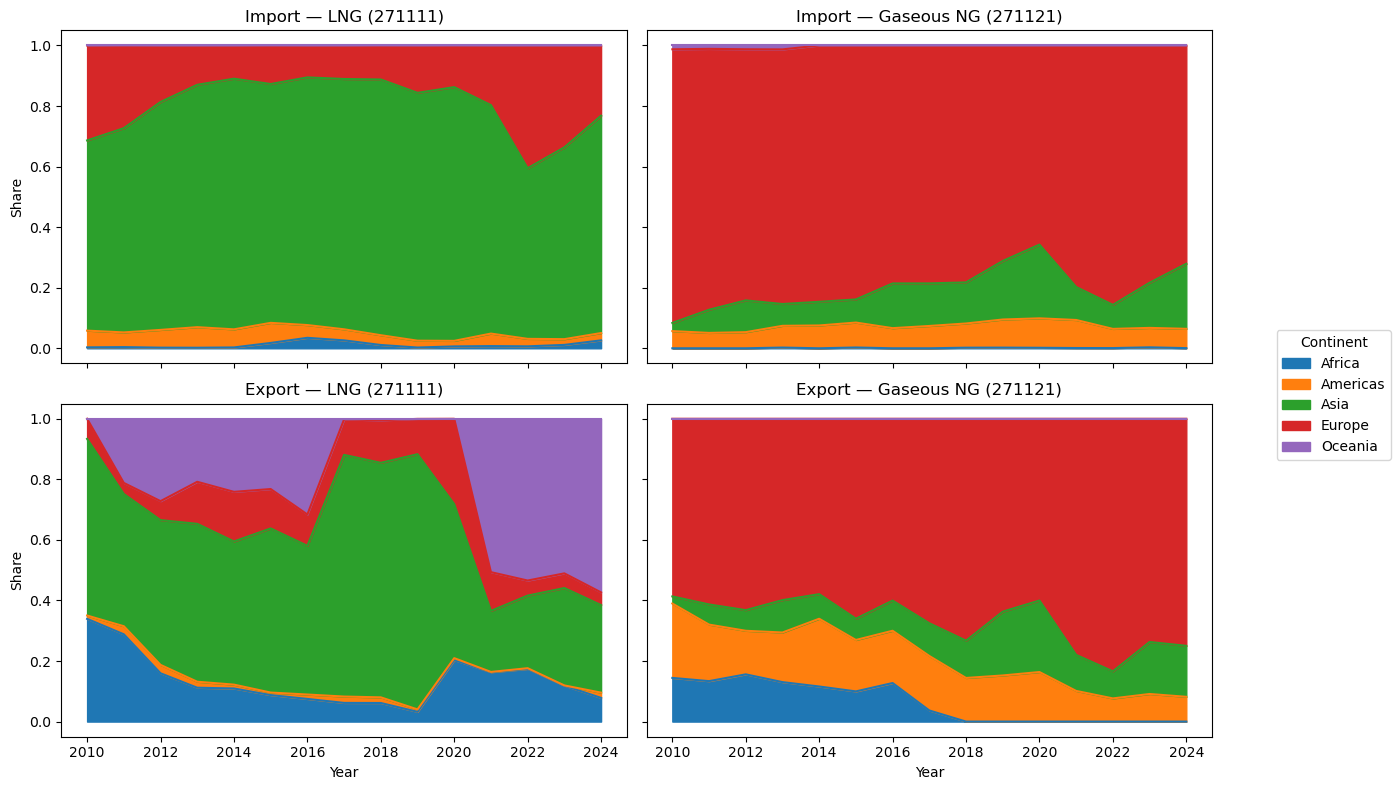

In [26]:
# Function to create a grid of shares stacked areas chart in 1 canvas
def plot_continent_shares(annual_cont, flows, products):
    fig, axes = plt.subplots(len(flows), len(products), figsize=(14,8), sharex=True, sharey=True)
    if len(flows) == 1 and len(products) == 1:
        axes = [[axes]]
    elif len(flows) == 1:
        axes = [axes]
    elif len(products) == 1:
        axes = [[ax] for ax in axes]

    for i, flow in enumerate(flows): # Loop through Import and export
        df = annual_cont[annual_cont["flow"] == flow].copy()
        df["total_value"] = df.groupby(["refYear", "product"])["value_usd"].transform("sum")
        df["share"] = df["value_usd"] / df["total_value"]

        for j, prod in enumerate(products): # Loop through LNG, Gaseous NG
            ax = axes[i][j] 
            tmp = (
                df[df["product"] == prod]
                .pivot(index="refYear", columns="continent", values="share")
                .fillna(0)
                .sort_index()
            )

            tmp.plot.area(ax=ax, legend=False)
            ax.set_title(f"{flow} — {prod}")
            ax.set_xlabel("Year")
            ax.set_ylabel("Share")

    handles, labels = axes[-1][-1].get_legend_handles_labels()
    fig.legend(handles, labels, title="Continent", loc="center right")
    plt.tight_layout(rect=[0, 0, 0.88, 1])  
    plt.show()

plot_continent_shares(
    annual_cont,
    flows=["Import", "Export"],
    products=["LNG (271111)", "Gaseous NG (271121)"]
)




Please find the explantionof the above plots:
    We see that Europe has dominated the Gaseous NG market, while Asia was primarily dependednt on LNG. But in 2022 we notice, due to the Russia-Ukraine war and disruption in pipeline supply, there is a signifincat share of Europe in the LNG market

    We see Ocenia, driven by Australia being one of the largest exporters of LNG has grown drastically over the several years. While Europe domiantes in gaseous ng market due to interconnected netweorks




In [27]:
# Country level analysis next

annual_country = (
    df_2010
    .groupby(
        ["refYear", "product", "flow", "reporterCode", "reporter"],
        as_index=False
    )
    .agg(value_usd=("primaryValue", "sum"))
)

annual_country.head()




,refYear,product,flow,reporterCode,reporter,value_usd
0,2010,Gaseous NG (271121),Export,12,Algeria,1.059942e+10
1,2010,Gaseous NG (271121),Export,32,Argentina,2.158250e+08
2,2010,Gaseous NG (271121),Export,36,Australia,2.768795e+04
3,2010,Gaseous NG (271121),Export,51,Armenia,1.410111e+07
4,2010,Gaseous NG (271121),Export,56,Belgium,6.209023e+09


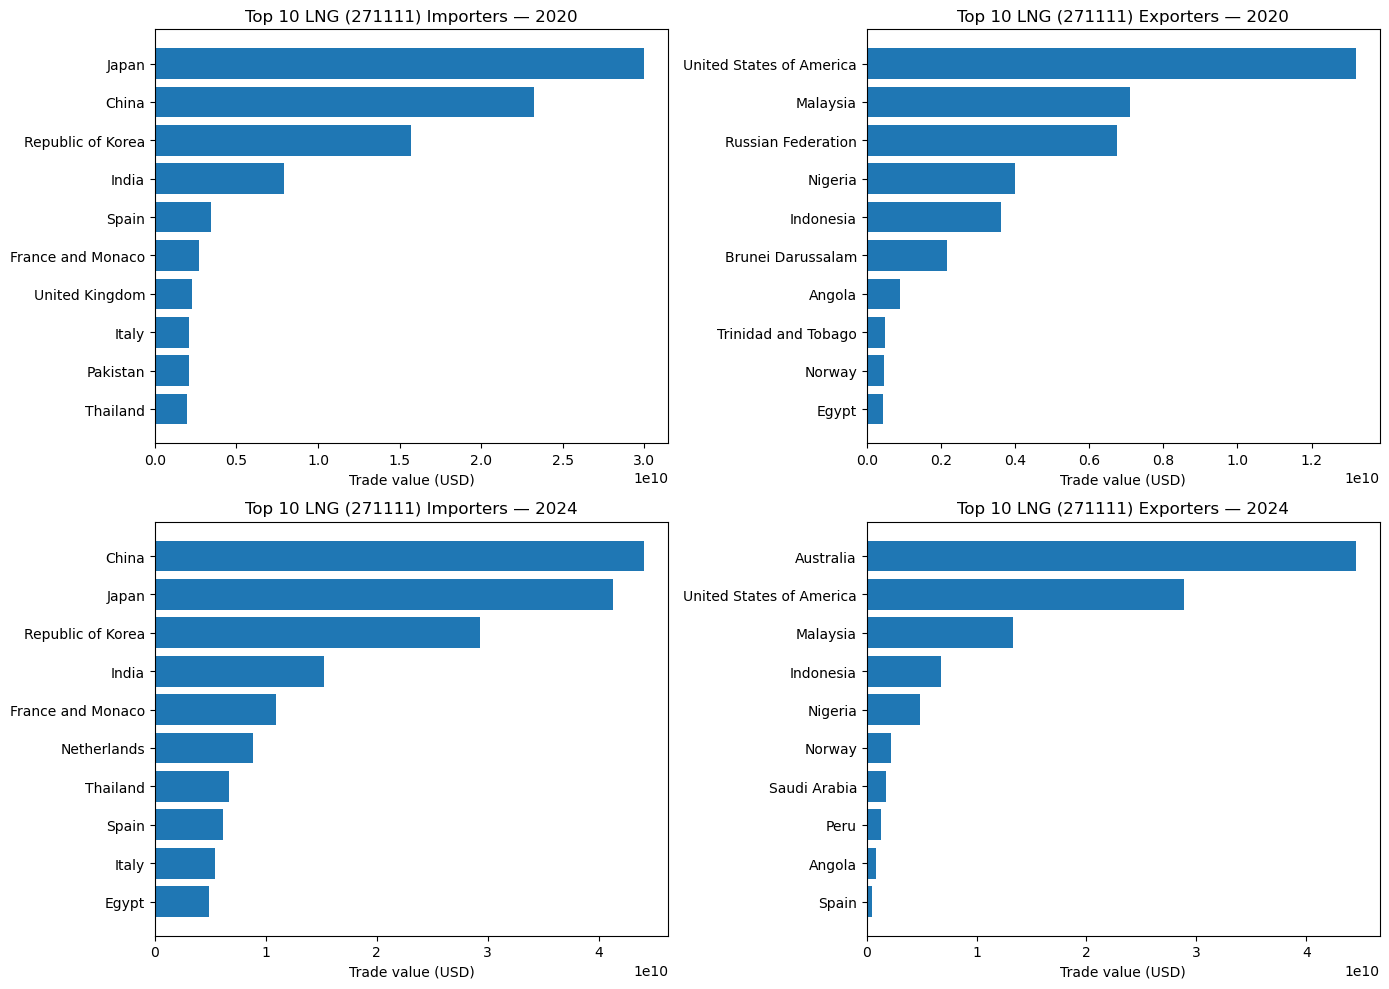

In [28]:
# Function to check top countries for both imports and exports (LNG)
def top_countries(
    df,
    year,
    product,
    flow=None,     
    n=20
):
    tmp = df[
        (df["refYear"] == year) &
        (df["product"] == product)
    ].copy()

    if flow is not None:
        tmp = tmp[tmp["flow"] == flow]

    tmp = tmp.sort_values("value_usd", ascending=False)
    tmp = tmp.head(n).copy()
    tmp["rank"] = range(1, len(tmp) + 1)

    cols = ["rank", "reporter", "flow", "value_usd"]
    return tmp[cols]

years = [2020, 2024]
N = 10
product = "LNG (271111)"

fig, axes = plt.subplots(nrows=len(years), ncols=2, figsize=(14,10), sharex=False)

for i, year in enumerate(years):
    # To get top N importers and exporters for LNG
     top_imp = top_countries(
        annual_country,
        year=year,
        product=product,
        flow="Import",
        n=N
    ).sort_values("value_usd")
     
     top_exp = top_countries(
        annual_country,
        year=year,
        product=product,
        flow="Export",
        n=N
    ).sort_values("value_usd")
     
    # Imports
     axes[i, 0].barh(top_imp["reporter"], top_imp["value_usd"])
     axes[i, 0].set_title(f"Top {N} {product} Importers — {year}")
     axes[i, 0].set_xlabel("Trade value (USD)")

    # Exports
     axes[i, 1].barh(top_exp["reporter"], top_exp["value_usd"])
     axes[i, 1].set_title(f"Top {N} {product} Exporters — {year}")
     axes[i, 1].set_xlabel("Trade value (USD)")

plt.tight_layout()
plt.show()



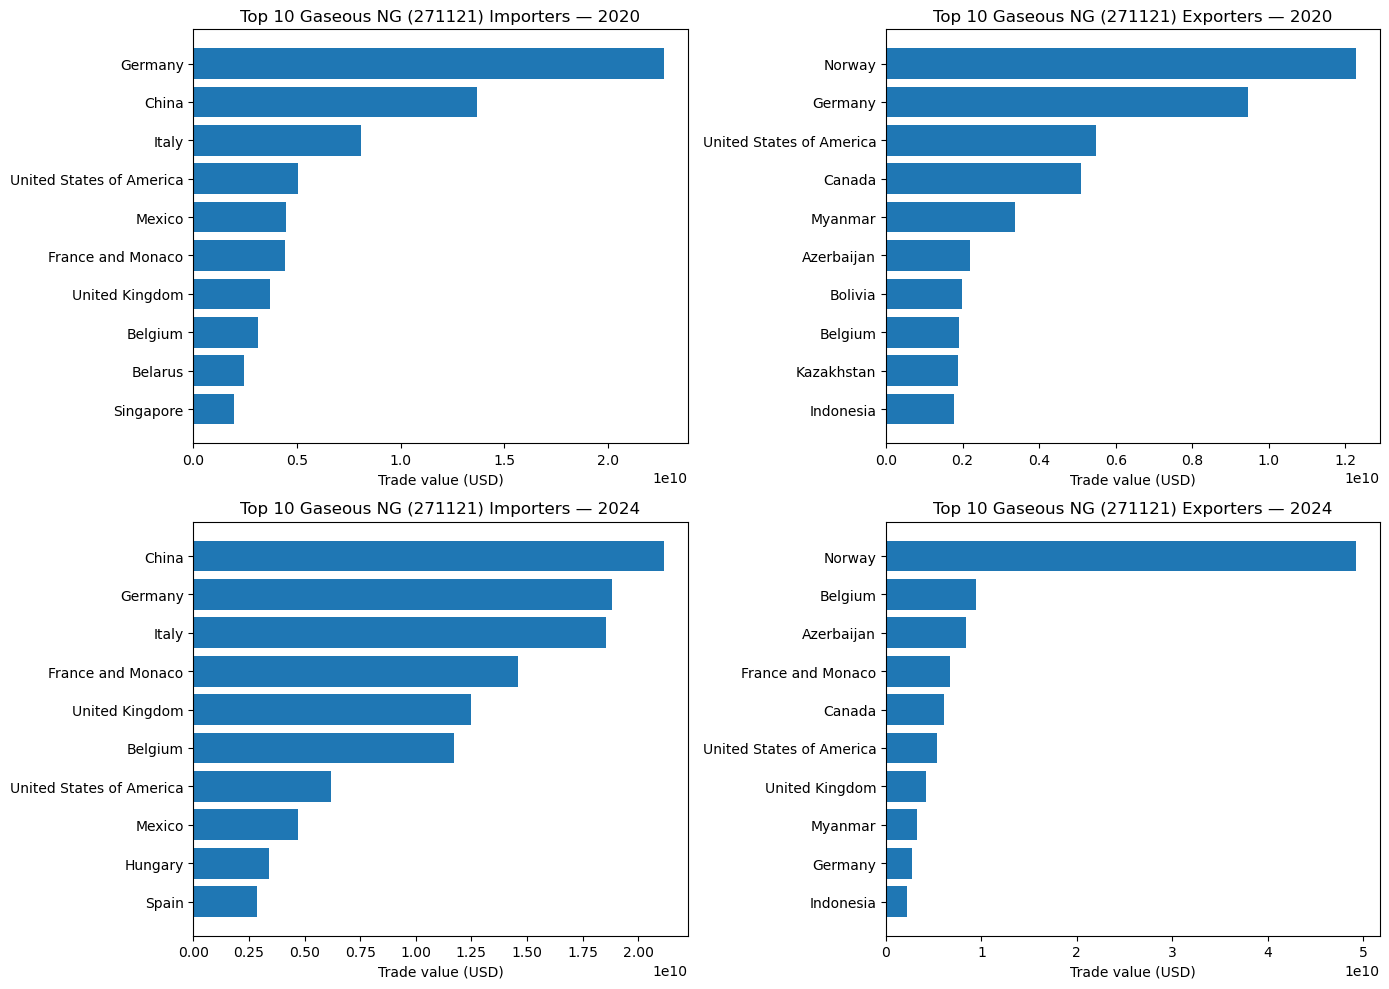

In [29]:
years = [2020, 2024]
N = 10
product = "Gaseous NG (271121)"

fig, axes = plt.subplots(nrows=len(years), ncols=2, figsize=(14, 10), sharex=False)

for i, year in enumerate(years):
    # Get top N importers/exporters for this year & product
    top_imp = top_countries(
        annual_country,
        year=year,
        product=product,
        flow="Import",
        n=N
    ).sort_values("value_usd")   # sort ascending for barh

    top_exp = top_countries(
        annual_country,
        year=year,
        product=product,
        flow="Export",
        n=N
    ).sort_values("value_usd")

    # IMPORTS
    axes[i, 0].barh(top_imp["reporter"], top_imp["value_usd"])
    axes[i, 0].set_title(f"Top {N} {product} Importers — {year}")
    axes[i, 0].set_xlabel("Trade value (USD)")

    # EXPORTS
    axes[i, 1].barh(top_exp["reporter"], top_exp["value_usd"])
    axes[i, 1].set_title(f"Top {N} {product} Exporters — {year}")
    axes[i, 1].set_xlabel("Trade value (USD)")

plt.tight_layout()
plt.show()


In [30]:
def plot_same_countries_import_export(annual_country, product, ref_year, compare_years, N=10):
    # Top-N importers in ref_year define the fixed country set
    order = (
        annual_country[
            (annual_country["refYear"] == ref_year) &
            (annual_country["product"] == product) &
            (annual_country["flow"] == "Import")
        ]
        .sort_values("value_usd", ascending=False)
        .head(N)["reporter"]
        .tolist()
    )

    fig, axes = plt.subplots(2, len(compare_years), figsize=(14, 9), sharey=True)

    for r, flow in enumerate(["Import", "Export"]):
        tmp = annual_country[
            (annual_country["product"] == product) &
            (annual_country["flow"] == flow) &
            (annual_country["refYear"].isin(compare_years)) &
            (annual_country["reporter"].isin(order))
        ]

        mat = (
            tmp.pivot_table(index="reporter", columns="refYear", values="value_usd", fill_value=0)
            .reindex(order)  
        )

        for c, y in enumerate(compare_years):
            ax = axes[r, c]
            vals = mat.get(y, pd.Series(0, index=mat.index))
            ax.barh(mat.index[::-1], vals.loc[mat.index[::-1]])
            ax.set_title(f"{flow}s — {y}")
            ax.set_xlabel("USD")
            if c == 0:
                ax.set_ylabel(f"{flow}\n(top {N} importers in {ref_year})")

    plt.suptitle(
        f"{product}: Imports (top) vs Exports (bottom) for SAME countries\n"
        f"Countries = Top {N} Importers in {ref_year} | Years = {compare_years[0]} vs {compare_years[1]}",
        y=0.98
    )
    plt.tight_layout()
    plt.show()


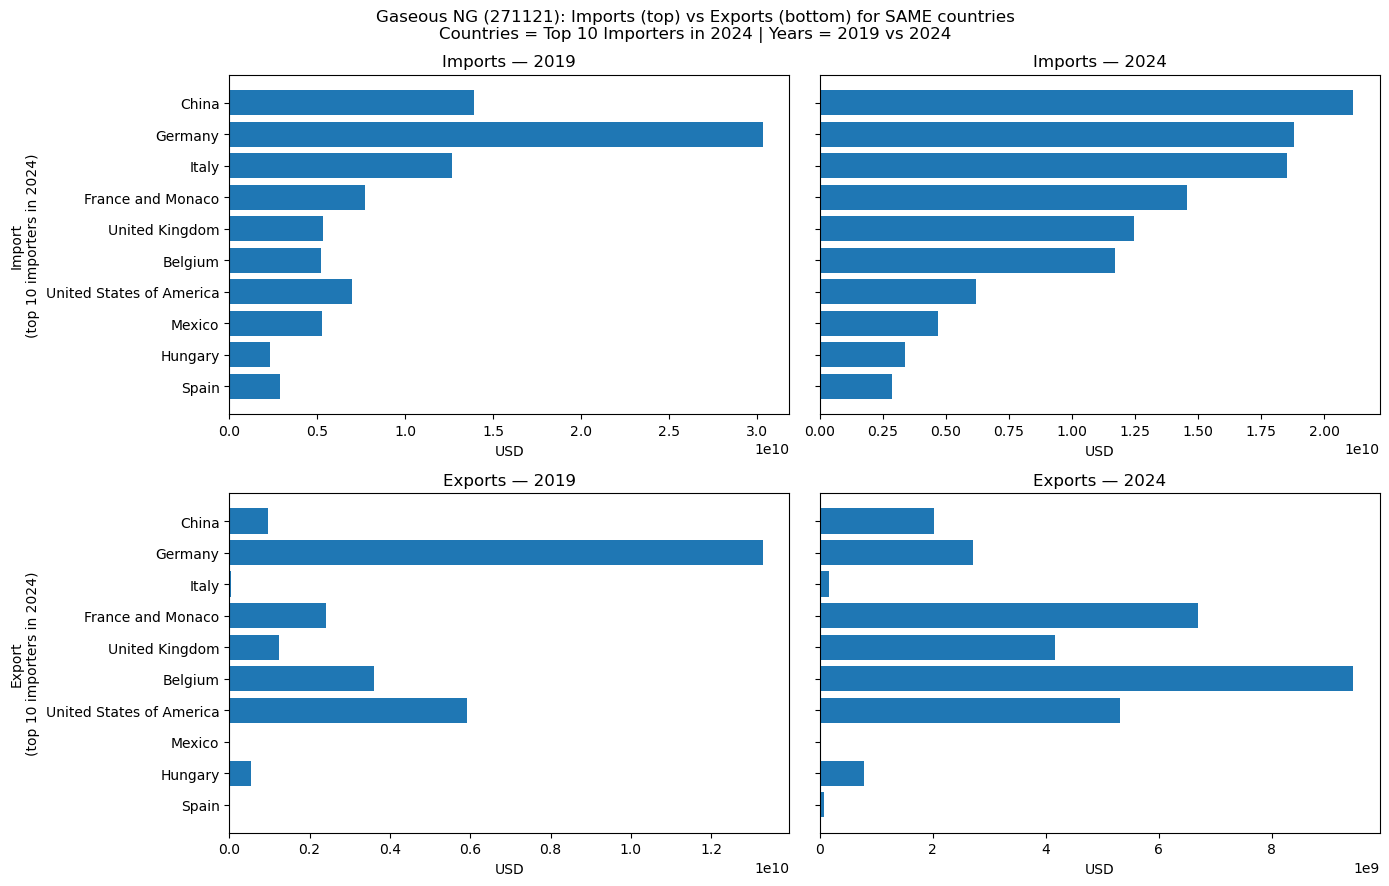

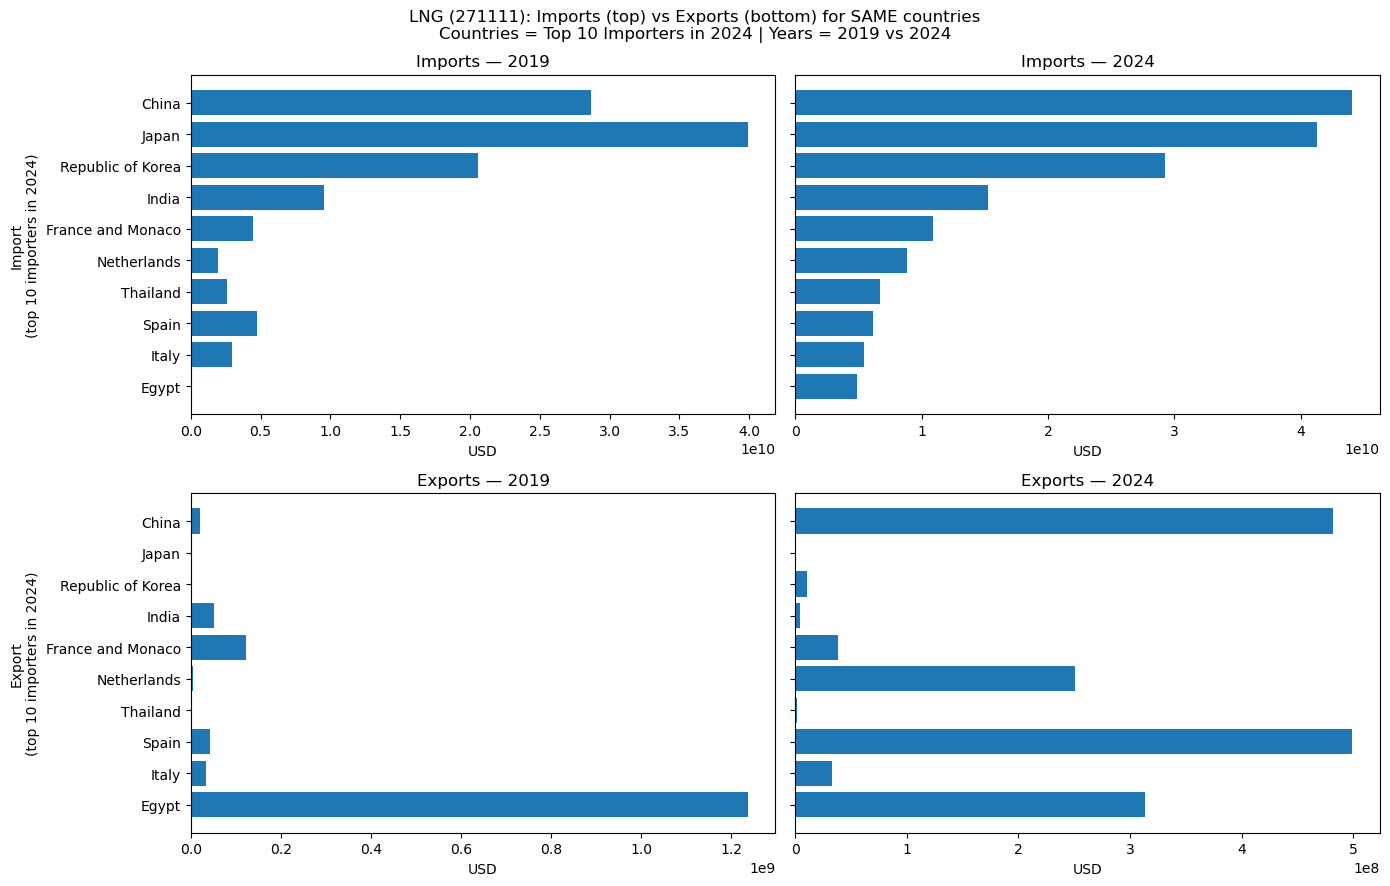

In [31]:
ref_year = 2024
compare_years = [2019, 2024]
N = 10

plot_same_countries_import_export(
    annual_country,
    product="Gaseous NG (271121)",
    ref_year=ref_year,
    compare_years=compare_years,
    N=N
)

plot_same_countries_import_export(
    annual_country,
    product="LNG (271111)",
    ref_year=ref_year,
    compare_years=compare_years,
    N=N
)


Seasonal Analysis


In [32]:
def prepare_monthly_imports(df_2010, value_col="primaryValue"):
    """
    Returns monthly import values aggregated by (refYear, month, product).
    Expects df to include: period (datetime), refYear, flow, product, value_col.
    """
    req_cols = {"period", "refYear", "flow", "product", value_col}
    missing = req_cols - set(df_2010.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    out = df_2010.copy()
    out["month"] = out["period"].dt.month

    out = out[out["flow"] == "Import"].copy()
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out[out[value_col].notna() & (out[value_col] >= 0)].copy()

    monthly = (
        out.groupby(["refYear", "month", "product"], as_index=False)
           .agg(value_usd=(value_col, "sum"))
    )
    return monthly

  


In [33]:
def add_annual_share(monthly_df):
    """
    Adds:
    - annual_total_usd per (refYear, product)
    - share = monthly value / annual total
    """
    out = monthly_df.copy()

    out["annual_total_usd"] = (
        out.groupby(["refYear", "product"])["value_usd"]
           .transform("sum")
    )

    out["share"] = np.where(
        out["annual_total_usd"] > 0,
        out["value_usd"] / out["annual_total_usd"],
        np.nan
    )

    return out

In [34]:
def make_heatmap_matrix(seasonality_df, product, value_col="share", year_min=2010, year_max=None):
    """
    Returns a pivot table: index=refYear, columns=month (1..12), values=value_col
    """
    tmp = seasonality_df[seasonality_df["product"] == product].copy()
    tmp = tmp[tmp["refYear"] >= year_min]
    if year_max is not None:
        tmp = tmp[tmp["refYear"] <= year_max]

    mat = (
        tmp.pivot_table(index="refYear", columns="month", values=value_col, aggfunc="mean")
           .reindex(columns=range(1, 13))
           .sort_index()
    )
    return mat

In [35]:
def plot_heatmap(mat, title, cmap="viridis"):
    """
    Plots a year x month heatmap using matplotlib imshow.
    mat: DataFrame with index=years and columns=months 1..12
    """
    plt.figure(figsize=(12, 6))

    # Convert to numpy for imshow
    data = mat.to_numpy()

    im = plt.imshow(data, aspect="auto", interpolation="nearest", cmap=cmap)

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Year")

    # Month labels
    plt.xticks(ticks=np.arange(12), labels=list(range(1, 13)))
    plt.yticks(ticks=np.arange(len(mat.index)), labels=mat.index)

    cbar = plt.colorbar(im)
    cbar.set_label("Monthly share of annual imports")

    plt.tight_layout()
    plt.show()


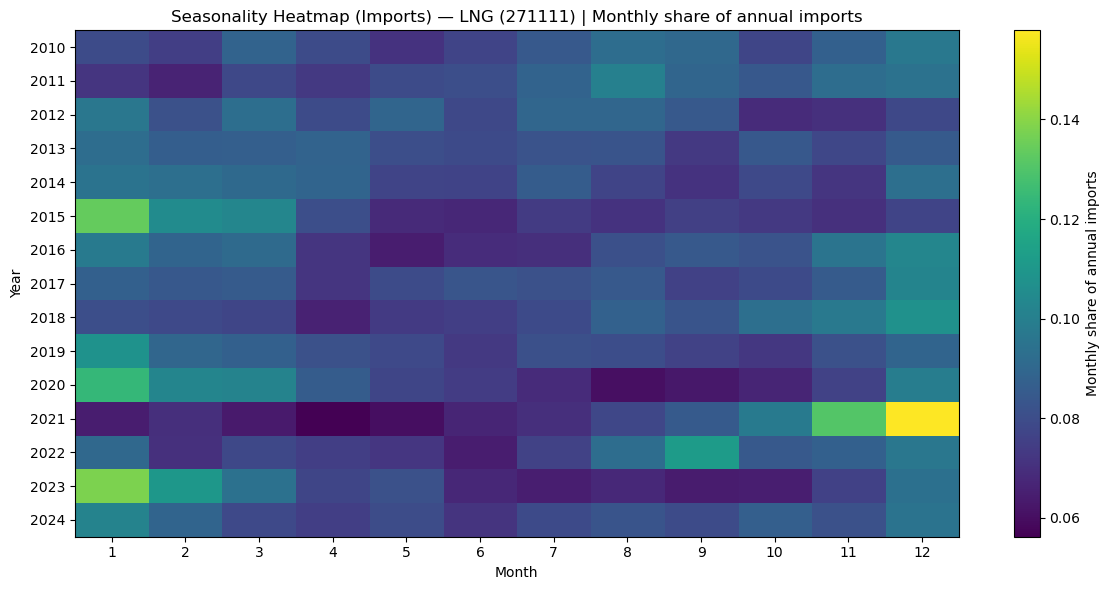

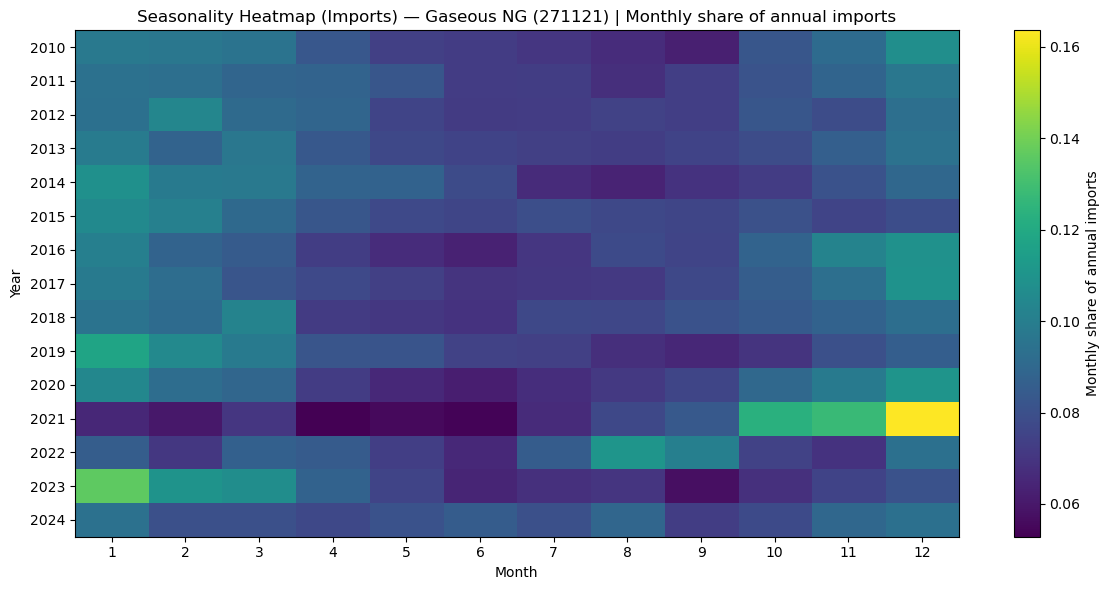

In [36]:

monthly = prepare_monthly_imports(df_2010, value_col="primaryValue")

seasonality = add_annual_share(monthly)

# Step 5.3: heatmaps
for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    mat = make_heatmap_matrix(seasonality, product=prod, value_col="share", year_min=2010)
    plot_heatmap(mat, title=f"Seasonality Heatmap (Imports) — {prod} | Monthly share of annual imports")


Please see the explaination of the above plots:
    Bright contibutes more to annual imports, while dark imorts contributes less.

    For LNG, we can characterize them by moderate seasonality. There is no extreme winter only concentration, imports are relatively spread across the year. This indicates LNG imports are structurally flexible and not purely heating-driven. Imports are consistent via storage and long term contratcs.

    Its important to note that we see a strong spile in Nov-Dec 2021, this reflects panic buying and early storage filling ahead of the 2022 energy crisis. Post 2022, seasonality becomes flatter, as such no single winter month dominates. Post-crisis we see normalization of the trend, where LNG imports are no longer concentrated in winter months, indicating precautionary procurement and storage-oriented behavior rather than reactive heating demand.


    For the Gaseous NG we see, the months Jan-Mar and Nov-Dec are consistently comparatively brighter, indicating heating driven seasonality. Like LNG we see, during the onset of the crisis 2021 winter month show a stronger spike.  During the summer months pipeline gas shows stronger troughs, indicating how its strongly tied to heating demand


In [37]:
def label_period(df_2010, pre_end_year=2021, post_start_year=2022, post_end_year=2024):
    """
    Adds a 'period_group' column:
      - 'Pre' for years <= pre_end_year
      - 'Post' for post_start_year..post_end_year
    """
    out = df_2010.copy()
    out["period_group"] = np.nan

    out.loc[out["refYear"] <= pre_end_year, "period_group"] = "Pre"
    out.loc[
        (out["refYear"] >= post_start_year) & (out["refYear"] <= post_end_year),
        "period_group"
    ] = "Post"

    return out


In [38]:
def seasonal_profile(seasonality_df, product, value_col="share"):
    """
    Returns a DataFrame with mean monthly share by (period_group, month)
    for a given product.
    """
    tmp = seasonality_df[seasonality_df["product"] == product].copy()
    tmp = tmp[tmp["period_group"].notna()].copy()

    prof = (
        tmp.groupby(["period_group", "month"], as_index=False)
           .agg(mean_share=(value_col, "mean"))
           .sort_values(["period_group", "month"])
    )
    return prof


In [39]:
def plot_seasonal_profile(profile_df, title):
    """
    profile_df: output of seasonal_profile()
    """
    plt.figure(figsize=(10, 4))

    for grp in ["Pre", "Post"]:
        sub = profile_df[profile_df["period_group"] == grp]
        plt.plot(sub["month"], sub["mean_share"], label=grp)

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Average monthly share of annual imports")
    plt.xticks(range(1, 13))
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\rauna\AppData\Local\Temp\ipykernel_13344\1269239665.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pre' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[out["refYear"] <= pre_end_year, "period_group"] = "Pre"


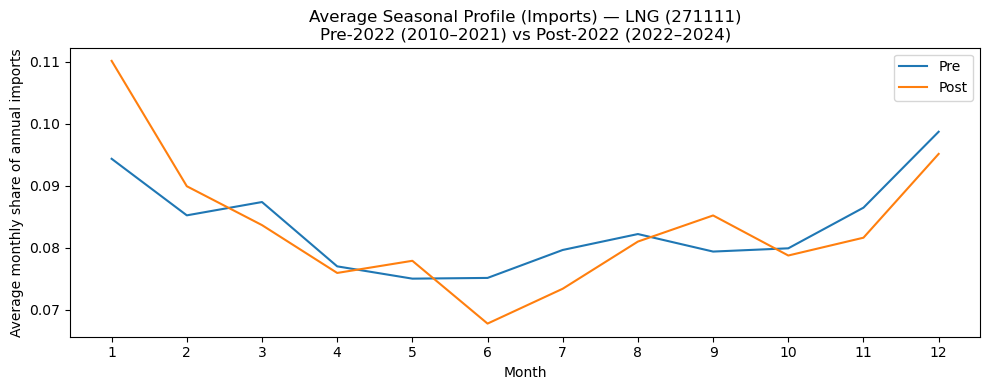

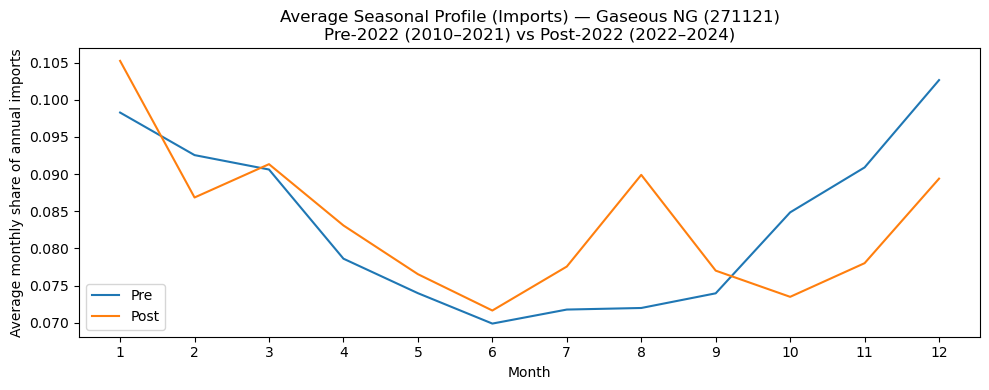

In [40]:
seasonality2 = label_period(seasonality, pre_end_year=2021, post_start_year=2022, post_end_year=2024)

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    prof = seasonal_profile(seasonality2, product=prod, value_col="share")
    plot_seasonal_profile(
        prof,
        title=f"Average Seasonal Profile (Imports) — {prod}\nPre-2022 (2010–2021) vs Post-2022 (2022–2024)"
    )


Please see the explaination of the above plots:

    For LNG pre 2022 we see Jan and decemver being slightly higher, and during the summer months we notice clear troughs, overall the seasonality is flat. Post 2022, we notice that there are much stronger January peaks, this indicates security of supply. Poat 2022, we see precuationary LNG procurement and early storage filling.

    For pipeline gas we notice a simialr trend, although it shows more seasonal patterns than LNG, both before and after the crisis. An additional point for both these graphs is, many countries and specifically the EU set strict gas storage deadlines post the crisis, thereby leading the front buying near the start of the year in order to ensure security.

In [41]:
def assign_regime(year):
    if 2010 <= year <= 2019:
        return "Pre-COVID"
    elif 2020 <= year <= 2021:
        return "COVID"
    elif 2022 <= year <= 2024:
        return "Crisis"
    else:
        return None  # keeping column as object when we cast it later

annual_country["regime"] = annual_country["refYear"].apply(assign_regime)

seasonality["regime"] = seasonality["refYear"].apply(assign_regime)

annual_country["regime"] = annual_country["regime"].astype("object")
seasonality["regime"] = seasonality["regime"].astype("object")





In [42]:
def regime_import_levels(annual_country):
    tmp = annual_country[
        (annual_country["flow"] == "Import") &
        (annual_country["regime"].notna())
    ].copy()

    out = (
        tmp.groupby(["product", "regime"], as_index=False)
           .agg(
               mean_import_usd=("value_usd", "mean"),
               median_import_usd=("value_usd", "median")
           )
    )
    return out

regime_levels = regime_import_levels(annual_country)
regime_levels


,product,regime,mean_import_usd,median_import_usd
0,Gaseous NG (271121),COVID,1.772987e+09,1.151831e+08
1,Gaseous NG (271121),Crisis,3.157207e+09,2.655700e+08
2,Gaseous NG (271121),Pre-COVID,1.892738e+09,1.326501e+08
3,LNG (271111),COVID,1.563281e+09,2.916601e+06
4,LNG (271111),Crisis,3.365692e+09,1.676526e+07
5,LNG (271111),Pre-COVID,1.387244e+09,2.847429e+05


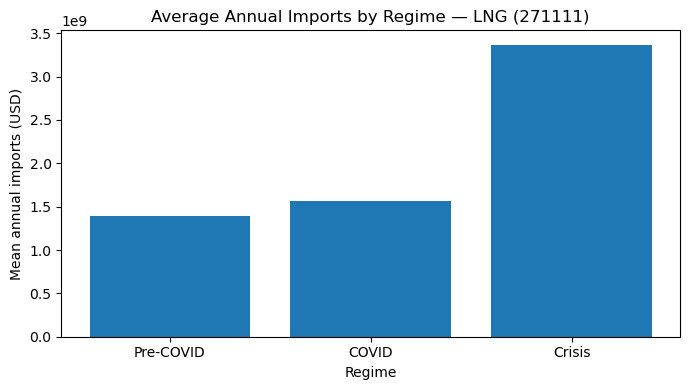

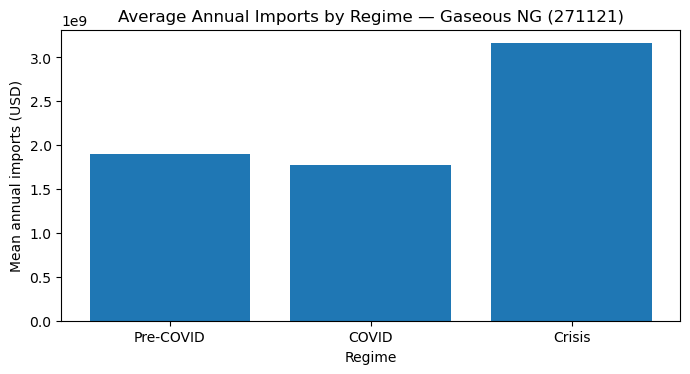

In [43]:
def plot_regime_levels(regime_levels, product):
    tmp = regime_levels[regime_levels["product"] == product].copy()
    order = ["Pre-COVID", "COVID", "Crisis"]
    tmp["regime"] = pd.Categorical(tmp["regime"], categories=order, ordered=True)
    tmp = tmp.sort_values("regime")

    plt.figure(figsize=(7,4))
    plt.bar(tmp["regime"], tmp["mean_import_usd"])
    plt.title(f"Average Annual Imports by Regime — {product}")
    plt.xlabel("Regime")
    plt.ylabel("Mean annual imports (USD)")
    plt.tight_layout()
    plt.show()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plot_regime_levels(regime_levels=regime_levels, product=prod)


Please see the explaination of the above plots:

    We see for LNG a moderate increase during the covid era and annual import values more than double in the crisis era relative to pre-covid times, clearly indicating the price driven effect

    We see for Pipeline gas , a slight decrease in the covid era initially and then a rapid increase in the crisis era, although smaller than LNG, implying LNG absorbing the adjustment burden during the crisis.


Scenario Testing


In [44]:
def regime_winter_intensity(seasonality):
    tmp = seasonality[
        seasonality["regime"].notna() &
        seasonality["share"].notna()
    ].copy()

    tmp["season"] = np.where(tmp["month"].isin([11, 12, 1, 2, 3]), "Winter", "Non-winter")

    out = (
        tmp.groupby(["product", "regime", "season"], as_index=False)
           .agg(avg_monthly_share=("share", "mean"))
    )
    return out

winter_tbl = regime_winter_intensity(seasonality)
winter_tbl


,product,regime,season,avg_monthly_share
0,Gaseous NG (271121),COVID,Non-winter,0.072698
1,Gaseous NG (271121),COVID,Winter,0.098222
2,Gaseous NG (271121),Crisis,Non-winter,0.078457
3,Gaseous NG (271121),Crisis,Winter,0.090160
4,Gaseous NG (271121),Pre-COVID,Non-winter,0.075467
5,Gaseous NG (271121),Pre-COVID,Winter,0.094347
6,LNG (271111),COVID,Non-winter,0.072168
7,LNG (271111),COVID,Winter,0.098965
8,LNG (271111),Crisis,Non-winter,0.077100
9,LNG (271111),Crisis,Winter,0.092060


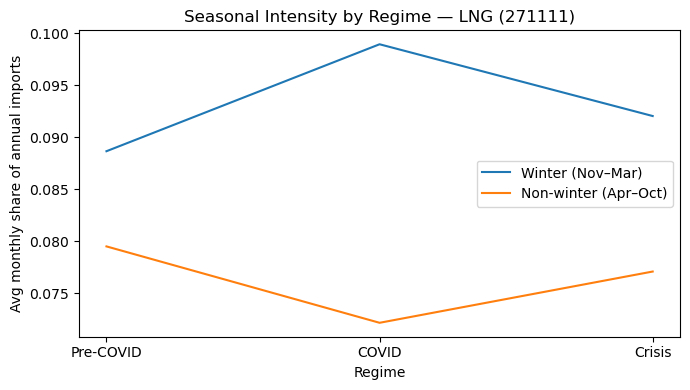

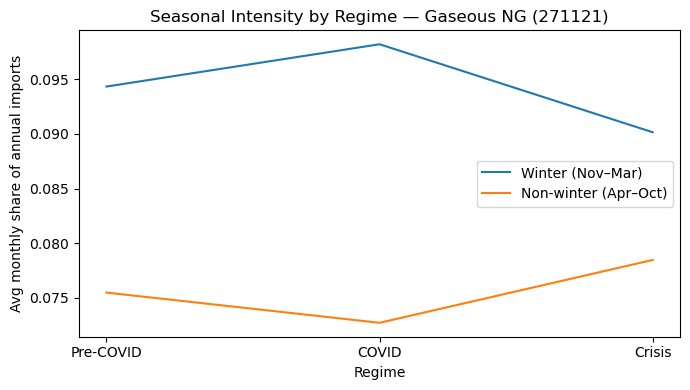

In [45]:
def plot_winter_vs_nonwinter(winter_tbl, product):
    tmp = winter_tbl[winter_tbl["product"] == product].copy()
    order = ["Pre-COVID", "COVID", "Crisis"]
    tmp["regime"] = pd.Categorical(tmp["regime"], categories=order, ordered=True)
    tmp = tmp.sort_values("regime")

    # pivot for easy plotting
    p = tmp.pivot(index="regime", columns="season", values="avg_monthly_share").reindex(order)

    plt.figure(figsize=(7,4))
    plt.plot(p.index, p["Winter"], label="Winter (Nov–Mar)")
    plt.plot(p.index, p["Non-winter"], label="Non-winter (Apr–Oct)")
    plt.title(f"Seasonal Intensity by Regime — {product}")
    plt.xlabel("Regime")
    plt.ylabel("Avg monthly share of annual imports")
    plt.legend()
    plt.tight_layout()
    plt.show()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plot_winter_vs_nonwinter(winter_tbl, prod)


In [46]:
def compute_baseline_seasonal_profile(seasonality_df, product, regime="Crisis"):
    """
    Computes the average monthly seasonal profile (shares sum to 1)
    for a given product and regime.
    """
    tmp = seasonality_df[
        (seasonality_df["product"] == product) &
        (seasonality_df["regime"] == regime)
    ].copy()

    baseline = (
        tmp.groupby("month", as_index=False)
           .agg(mean_share=("share", "mean"))
           .sort_values("month")
    )

    # Normalise explicitly (numerical safety)
    baseline["mean_share"] = baseline["mean_share"] / baseline["mean_share"].sum()

    return baseline




In [47]:
baseline_lng = compute_baseline_seasonal_profile(
    seasonality_df=seasonality,
    product="LNG (271111)",
    regime="Crisis"
)

baseline_lng

baseline_lng["mean_share"].sum()



baseline_gas = compute_baseline_seasonal_profile(
    seasonality_df=seasonality,
    product="Gaseous NG (271121)",
    regime="Crisis"
)


baseline_gas["mean_share"].sum()

np.float64(1.0)

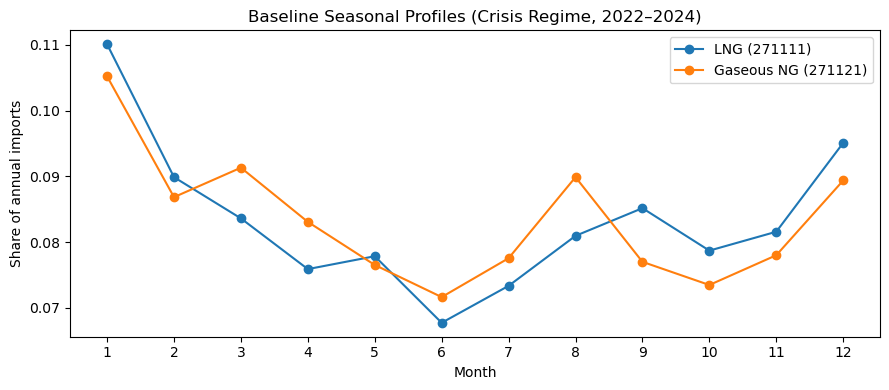

In [48]:
def plot_seasonal_profiles(dfs, labels, title):
    plt.figure(figsize=(9,4))
    
    for df, label in zip(dfs, labels):
        plt.plot(df["month"], df["mean_share"], marker="o", label=label)
    
    plt.xlabel("Month")
    plt.ylabel("Share of annual imports")
    plt.xticks(range(1, 13))
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_seasonal_profiles(
    dfs=[baseline_lng, baseline_gas],
    labels=["LNG (271111)", "Gaseous NG (271121)"],
    title="Baseline Seasonal Profiles (Crisis Regime, 2022–2024)"
)


Above we see that plot of beaseline seasonal profiles, constructed from crisis regime data (2022-2024), keeping in mind that 2024,indicates a normalization trend. This graph confirms how importers now secure a large share of their annual volume in January to mitigate supply risk. LNG serves as a flexible baseload which can be diverted when needed.

From this we see that the crisis did not elimate seasonality, LNG was smoother and front loaded, while pipeline ng was structurally seasonal.


In [49]:
# Winter Stress Scenario - Main question, What if winter dependence re-intensifies relative to the post-crisis baseline?

WINTER_MONTHS = {11, 12, 1, 2}

def apply_winter_stress(baseline_df, stress_pct=0.20, winter_months = WINTER_MONTHS):

    """
    Applies a proportional winter stress to a seasonal profile.
    baseline_df: DataFrame with columns ['month', 'mean_share'] that sum to 1.
    stress_pct: e.g. 0.20 for +20% winter stress.
    Returns a new DataFrame with stressed shares (sum to 1).
    """
    stressed = baseline_df.copy()
    # Split winter vs non-winter
    is_winter = stressed["month"].isin(winter_months)
    
    # Applying winter stress to all specified months
    stressed.loc[is_winter, "mean_share"] *= (1 + stress_pct)

    # Renormalise to one, to maintain proportionality
    stressed["mean_share"] =  stressed["mean_share"] / stressed["mean_share"].sum()

    return stressed


    

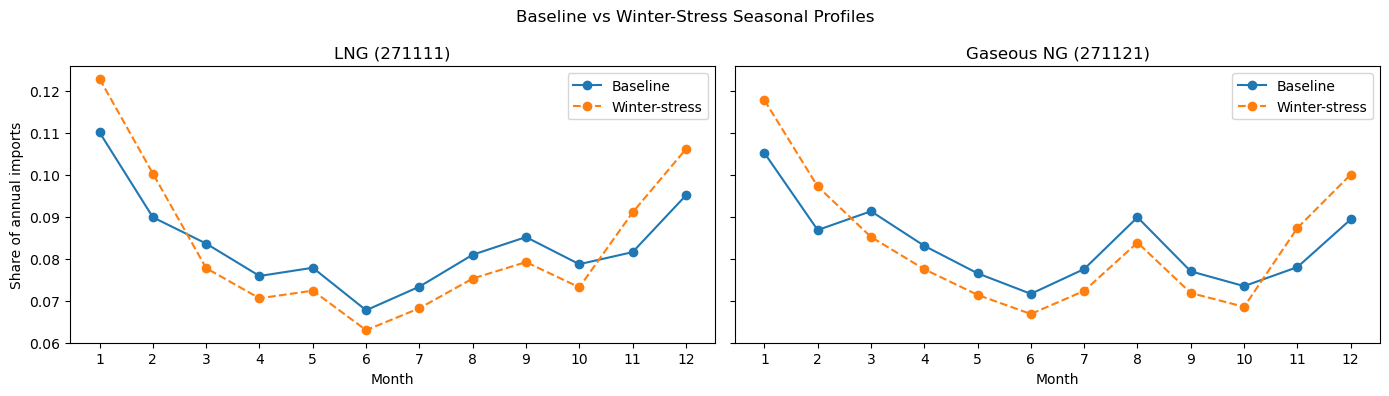

In [50]:
stress_lng = apply_winter_stress(baseline_lng, stress_pct=0.20)
stress_gas = apply_winter_stress(baseline_gas, stress_pct=0.20)

def plot_side_by_side(baseline_lng, stress_lng, baseline_gas, stress_gas):
    fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)

    axes[0].plot(baseline_lng["month"], baseline_lng["mean_share"], marker="o", label="Baseline")
    axes[0].plot(stress_lng["month"], stress_lng["mean_share"], marker="o", linestyle="--", label="Winter-stress")
    axes[0].set_title("LNG (271111)")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Share of annual imports")
    axes[0].set_xticks(range(1,13))
    axes[0].legend()

    axes[1].plot(baseline_gas["month"], baseline_gas["mean_share"], marker="o", label="Baseline")
    axes[1].plot(stress_gas["month"], stress_gas["mean_share"], marker="o", linestyle="--", label="Winter-stress")
    axes[1].set_title("Gaseous NG (271121)")
    axes[1].set_xlabel("Month")
    axes[1].set_xticks(range(1,13))
    axes[1].legend()

    plt.suptitle("Baseline vs Winter-Stress Seasonal Profiles")
    plt.tight_layout()
    plt.show()

plot_side_by_side(baseline_lng, stress_lng, baseline_gas, stress_gas)


Applying a winter-stress shock to the post-crisis baseline reveals asymmetric adjustment mechanisms across natural gas transport modes. LNG exhibits a pronounced increase in winter concentration under stress, indicating a partial reaction toward reactive winter procurement when flexibility is required to absorb shocks. In contrast, pipeline gas displays only marginal changes, reflecting its structurally rigid and winter-dominated nature. These results highlight LNG’s role as a shock absorber in global gas markets, while also underscoring the limits of its flexibility under renewed winter pressure.

In [51]:
# Now we check the opposite scenario, What if LNG market flexibility continues to improve and imports become more evenly distributed across the year?

def apply_diversification(baseline_df, alpha=0.30):
    """
    Flattens a seasonal profile toward uniform distribution.
    alpha = share of uniform distribution mixed in (e.g. 0.30).
    """
    diversified = baseline_df.copy()
    uniform_share = 1.0 / 12.0

    diversified["mean_share"] = (
        (1 - alpha) * diversified["mean_share"] +
        alpha * uniform_share
    )

    # Numerical safety
    diversified["mean_share"] = diversified["mean_share"] / diversified["mean_share"].sum()

    return diversified



In [52]:
def plot_baseline_vs_diversified(baseline_df, diversified_df, title):
    plt.figure(figsize=(9,4))
    plt.plot(baseline_df["month"], baseline_df["mean_share"], marker="o", label="Baseline")
    plt.plot(diversified_df["month"], diversified_df["mean_share"], marker="o", linestyle="--", label="Diversification")
    plt.xlabel("Month")
    plt.ylabel("Share of annual imports")
    plt.xticks(range(1, 13))
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


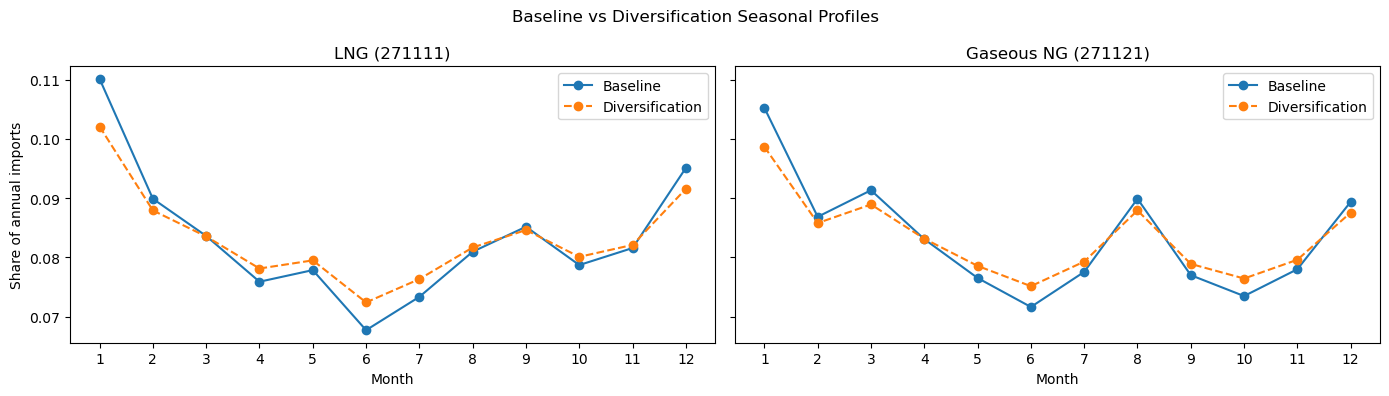

In [53]:
div_lng = apply_diversification(baseline_lng, alpha=0.30)
div_gas = apply_diversification(baseline_gas, alpha=0.30)

def plot_diversification_side_by_side(baseline_lng, div_lng, baseline_gas, div_gas):
    fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)

    axes[0].plot(baseline_lng["month"], baseline_lng["mean_share"], marker="o", label="Baseline")
    axes[0].plot(div_lng["month"], div_lng["mean_share"], marker="o", linestyle="--", label="Diversification")
    axes[0].set_title("LNG (271111)")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Share of annual imports")
    axes[0].set_xticks(range(1,13))
    axes[0].legend()

    axes[1].plot(baseline_gas["month"], baseline_gas["mean_share"], marker="o", label="Baseline")
    axes[1].plot(div_gas["month"], div_gas["mean_share"], marker="o", linestyle="--", label="Diversification")
    axes[1].set_title("Gaseous NG (271121)")
    axes[1].set_xlabel("Month")
    axes[1].set_xticks(range(1,13))
    axes[1].legend()

    plt.suptitle("Baseline vs Diversification Seasonal Profiles")
    plt.tight_layout()
    plt.show()

plot_diversification_side_by_side(baseline_lng, div_lng, baseline_gas, div_gas)


The diversification scenario highlights the asymmetric resilience gains across natural gas transport modes. LNG imports exhibit a flattening of the seasonal profile, with reduced winter peaks and elevated mid-year imports, indicating substantial potential for risk mitigation through diversification and improved flexibility. In contrast, pipeline gas displays only modest changes under diversification, reflecting persistent infrastructural constraints. These findings suggest that future resilience improvements in global gas markets are primarily driven by LNG rather than pipeline-based supply

In [54]:
# Diagnostic Predictive model - A simple time series diagnostic to validate the regime changes we were talking about earlier.

"""
We make a simple seasonal time-series model with:
    Monthly imports (USD)
    One global Series/Product

    Train data = 2010 - 2019 (Normal)

"""
monthly_imports = (
    df_2010[df_2010["flow"] == "Import"]
    .groupby(["period", "product"], as_index=False)
    .agg(value_usd=("primaryValue", "sum"))
)

# monthly_imports.head()

monthly_imports = monthly_imports.sort_values("period")


In [55]:
train_end = "2019-12-31"


In [56]:
def seasonal_naive_forecast(series, horizon=12):
    """
    series: pandas Series with DateTimeIndex
    """
    return series.shift(12)


In [57]:
lng_series = (
    monthly_imports[monthly_imports["product"] == "LNG (271111)"]
    .set_index("period")["value_usd"]
)


lng_pred = seasonal_naive_forecast(lng_series)


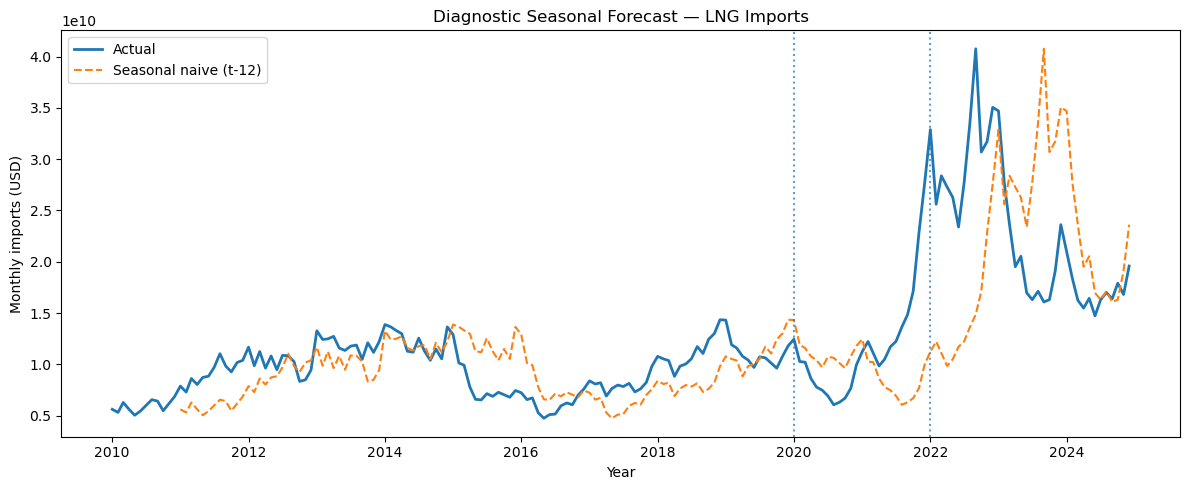

In [58]:
plt.figure(figsize=(12,5))
plt.plot(lng_series, label="Actual", linewidth=2)
plt.plot(lng_pred, label="Seasonal naive (t-12)", linestyle="--")

plt.axvline(pd.to_datetime("2020-01-01"), linestyle=":", alpha=0.7)
plt.axvline(pd.to_datetime("2022-01-01"), linestyle=":", alpha=0.7)

plt.title("Diagnostic Seasonal Forecast — LNG Imports")
plt.ylabel("Monthly imports (USD)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


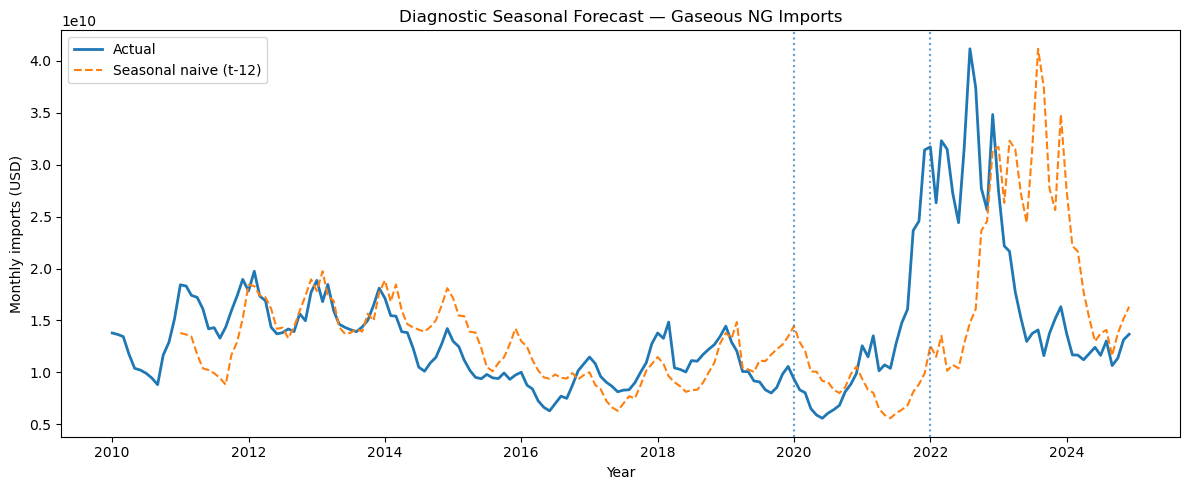

In [59]:
gas_series = (
    monthly_imports[monthly_imports["product"] == "Gaseous NG (271121)"]
    .set_index("period")["value_usd"]
)

gas_pred = seasonal_naive_forecast(gas_series)

plt.figure(figsize=(12,5))
plt.plot(gas_series, label="Actual", linewidth=2)
plt.plot(gas_pred, label="Seasonal naive (t-12)", linestyle="--")

plt.axvline(pd.to_datetime("2020-01-01"), linestyle=":", alpha=0.7)
plt.axvline(pd.to_datetime("2022-01-01"), linestyle=":", alpha=0.7)

plt.title("Diagnostic Seasonal Forecast — Gaseous NG Imports")
plt.ylabel("Monthly imports (USD)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


A seasonal naïve benchmark model, trained on pre-2020 data, performs reasonably well until 2019 and exhibits only moderate deviations during the COVID period. However, following 2022, the model fails systematically for LNG imports, with persistent under- and over-prediction and a breakdown of historical seasonal patterns. This behavior provides strong diagnostic evidence of a structural regime change in LNG trade dynamics rather than a temporary shock. Pipeline gas imports display smaller forecast deviations and retain part of their historical seasonal structure, reflecting greater rigidity but lower adaptability.